# Strategy map generation pipeline

Visualize each stage of `scripts/generate_tool_strategy_maps.py`:

1. Per-class RGB color ramps (height → color legend).
2. Raw `generate_island` heightmaps (1 per biome).
3. Per-biome modifications (highland adds a ridge).
4. Final: center-crop + berry overlay + deadly border + colorize.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import generate_strategy_maps as gt

BASE_SEED = 1
BIOMES = gt.ALL_BIOMES
print('Biomes:', BIOMES)
print(f'Gen size:  {gt.GEN_SIZE}×{gt.GEN_SIZE}')
print(f'Crop size: {gt.CROP_SIZE}×{gt.CROP_SIZE}')
print(f'Berry target: {gt.BERRY_FRAC:.0%} of tiles')

Biomes: ['balanced', 'archipelago', 'highland', 'grassland']
Gen size:  170×170
Crop size: 128×128
Berry target: 2% of tiles


## 1. Height → RGB ramps

Each terrain class maps a height range to a gradient between two pastel colors. Berry and deadly tiles are solid overrides.

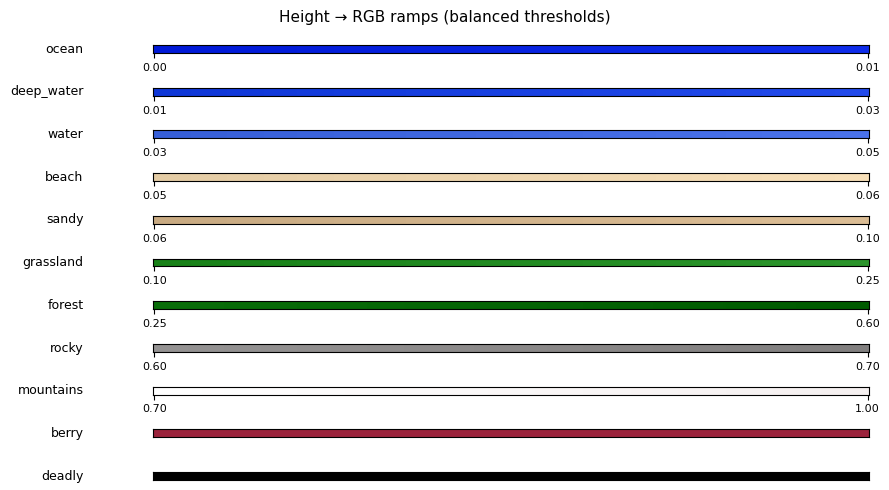

In [2]:
def show_ramps(biome: str = 'balanced'):
    names = gt.TERRAIN_NAMES
    thr = gt.BIOME_THRESHOLDS[biome]
    lower = np.concatenate(([0.0], thr[:-1]))

    rows = names + ['berry', 'deadly']
    fig, axes = plt.subplots(len(rows), 1, figsize=(9, 0.45 * len(rows)))

    for i, name in enumerate(names):
        lo_c = np.array(gt.CLASS_RAMPS[name][0], dtype=np.float32)
        hi_c = np.array(gt.CLASS_RAMPS[name][1], dtype=np.float32)
        t = np.linspace(0, 1, 256)[None, :]
        grad = (lo_c[None, None, :] * (1 - t[..., None]) + hi_c[None, None, :] * t[..., None])
        grad = np.broadcast_to(grad, (1, 256, 3)).astype(np.uint8)
        ax = axes[i]
        ax.imshow(grad, aspect='auto')
        ax.set_yticks([])
        ax.set_xticks([0, 255])
        ax.set_xticklabels([f'{lower[i]:.2f}', f'{thr[i]:.2f}'], fontsize=8)
        ax.set_ylabel(name, rotation=0, labelpad=50, ha='right', fontsize=9, va='center')

    for j, (name, color) in enumerate([('berry', gt.BERRY_COLOR), ('deadly', gt.DEADLY_COLOR)]):
        ax = axes[len(names) + j]
        strip = np.full((1, 256, 3), color, dtype=np.uint8)
        ax.imshow(strip, aspect='auto')
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_ylabel(name, rotation=0, labelpad=50, ha='right', fontsize=9, va='center')

    fig.suptitle(f"Height → RGB ramps ({biome} thresholds)", fontsize=11)
    plt.tight_layout()
    plt.show()

show_ramps('balanced')

## 2. Raw heightmaps

Straight `generate_island` output at `GEN_SIZE`, one per biome (each biome differs by `sink_mode`).

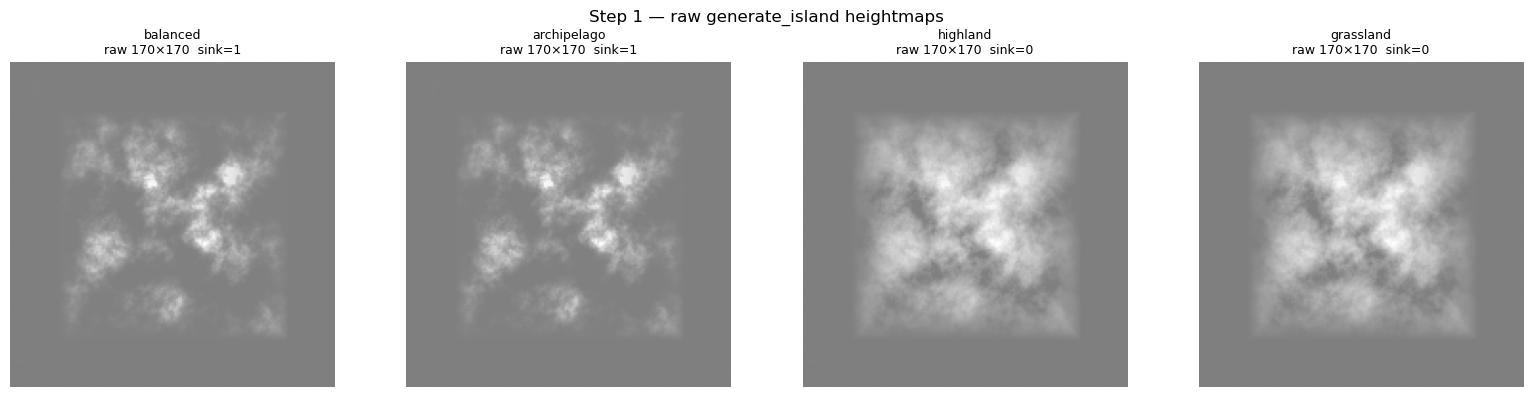

In [3]:
raw_hms = {b: gt.generate_raw_heightmap(BASE_SEED, b) for b in BIOMES}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, b in zip(axes, BIOMES):
    ax.imshow(raw_hms[b], cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f"{b}\nraw {gt.GEN_SIZE}×{gt.GEN_SIZE}  sink={gt.BIOME_SINK_MODE[b]}", fontsize=9)
    ax.set_axis_off()
fig.suptitle('Step 1 — raw generate_island heightmaps', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Per-biome modifications

Only `highland` is changed here — a noise-warped ridge line is added to bias toward mountainous spines. The other biomes pass through unchanged.

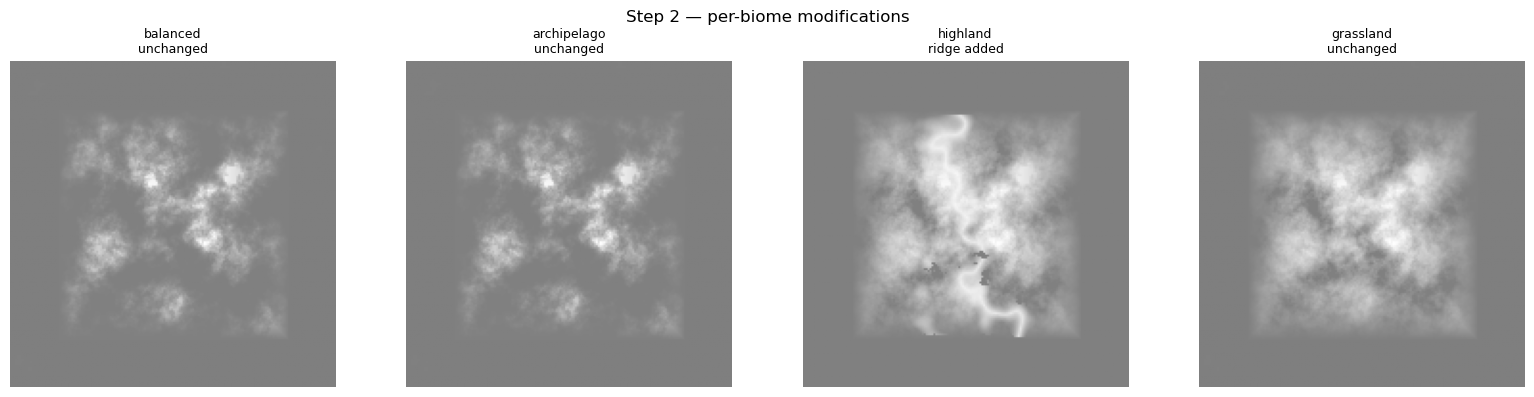

In [4]:
mod_hms = {b: gt.apply_biome_mods(raw_hms[b], b, BASE_SEED) for b in BIOMES}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, b in zip(axes, BIOMES):
    ax.imshow(mod_hms[b], cmap='gray', vmin=-1, vmax=1)
    delta = 'ridge added' if b == 'highland' else 'unchanged'
    ax.set_title(f"{b}\n{delta}", fontsize=9)
    ax.set_axis_off()
fig.suptitle('Step 2 — per-biome modifications', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Crop + berries + deadly border + colorize

Center-crop `GEN_SIZE→CROP_SIZE`, sample berry tiles (height-weighted on forest, ~5% of total), paint the 1-pixel deadly border, colorize with the pastel ramps.

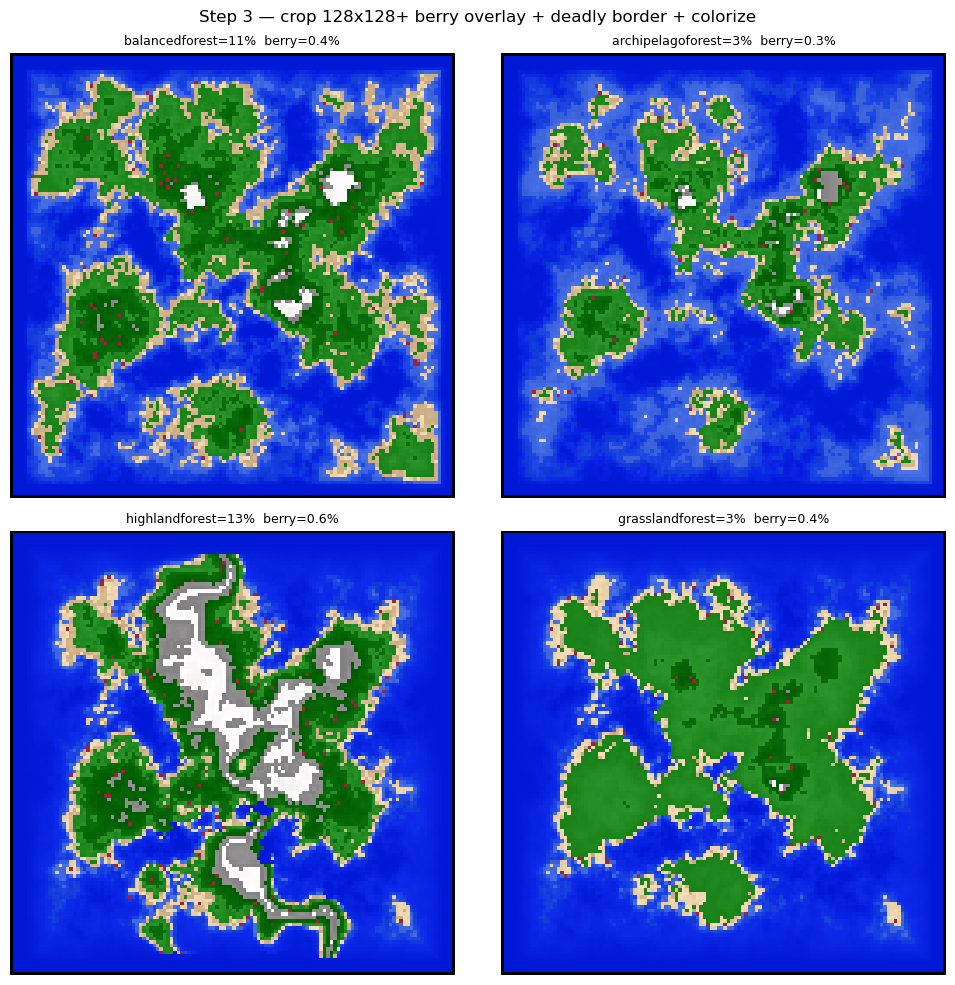

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, b in zip(axes.flatten(), BIOMES):
    m = gt.generate_strategy_map(BASE_SEED, b)
    rgb = gt.colorize_gradient(m.heightmap.numpy(), b, m.berry_mask.numpy())
    ax.imshow(rgb, interpolation='nearest')
    f = m.terrain_fractions
    berry_frac = m.berry_mask.float().mean().item()
    ax.set_title(
        f"{b}"
        f"forest={f.get('forest', 0):.0%}  berry={berry_frac:.1%}",
        fontsize=9,
    )
    ax.set_axis_off()
fig.suptitle('Step 3 — crop 128x128+ berry overlay + deadly border + colorize', fontsize=12)
plt.tight_layout()
plt.show()